# Plot Saved Multispecies Slow-Mode Outputs

This notebook imports saved output from the generation notebook. It does not recompute PCA, wavelets, k-means, or G-PCCA.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path('/Users/meganbishop/slowmodeevo').resolve()

def find_projection_run_root():
    base = REPO_ROOT / 'outputs/single_species_distance_comparison'
    candidates = [base / value for value in ['pca_multispecies_evensamp' ,'multispecies_pca_wavelet_pca/pca_before_wavelet_pca_after_multispecies', 'pca_before_wavelet_pca_after_multispecies']]
    candidates.extend(
        sorted(
            [path for path in base.glob('**/projection_files_manifest.csv')],
            key=lambda path: path.stat().st_mtime,
            reverse=True,
        )[index].parent
        for index in range(len(list(base.glob('**/projection_files_manifest.csv'))))
    )
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        required = [
            candidate / 'projection_generation_summary.csv',
            candidate / 'multispecies_individual_manifest.csv',
            candidate / 'projection_files_manifest.csv',
        ]
        if all(path.exists() for path in required):
            return candidate
    raise FileNotFoundError(
        'Could not find a completed multispecies projection run under '
        f'{base}. Expected projection_generation_summary.csv, '
        'multispecies_individual_manifest.csv, and projection_files_manifest.csv.'
    )

RUN_ROOT = find_projection_run_root()
PLOT_DIR = RUN_ROOT / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_CSV = RUN_ROOT / 'projection_generation_summary.csv'
INDIVIDUAL_MANIFEST_CSV = RUN_ROOT / 'multispecies_individual_manifest.csv'
PROJECTION_MANIFEST_CSV = RUN_ROOT / 'projection_files_manifest.csv'

summary = pd.read_csv(SUMMARY_CSV)
manifest = pd.read_csv(INDIVIDUAL_MANIFEST_CSV)
projection_inventory = pd.read_csv(PROJECTION_MANIFEST_CSV)

print(f'RUN_ROOT = {RUN_ROOT}')
display(summary)
display(manifest.groupby('species').size().rename('n_individuals').reset_index())

RUN_ROOT = /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/pca_multispecies_evensamp


,run_name,run_root,n_species,n_individuals,pre_wavelet_pca_components,pre_wavelet_pca_variance,post_wavelet_pca_components,post_wavelet_pca_selection_mode,post_wavelet_pca_variance_target,post_wavelet_pca_target_reached,wavelet_subsample_factor,normalize_wavelets_for_pca,pre_wavelet_pca_balance_samples_by_species,post_wavelet_pca_balance_samples_by_species,pre_wavelet_pca_fit_method,post_wavelet_pca_fit_method,projection_result,projection_files_manifest
0,pca_multispecies_evensamp,/Users/meganbishop/slowmodeevo/outputs/single_...,8,354,28,0.990521,100,variance_target,0.99,False,50,True,True,True,streaming_covariance,streaming_covariance,/Users/meganbishop/slowmodeevo/outputs/single_...,/Users/meganbishop/slowmodeevo/outputs/single_...


,species,n_individuals
0,Mus_caroli,15
1,Mus_musculus,93
2,Mus_spretus,16
3,Peromyscus_californicus,23
4,Peromyscus_gossypinus,20
5,Peromyscus_leucopus,14
6,Peromyscus_maniculatus,129
7,Peromyscus_polionotus,44


## PCA Diagnostics

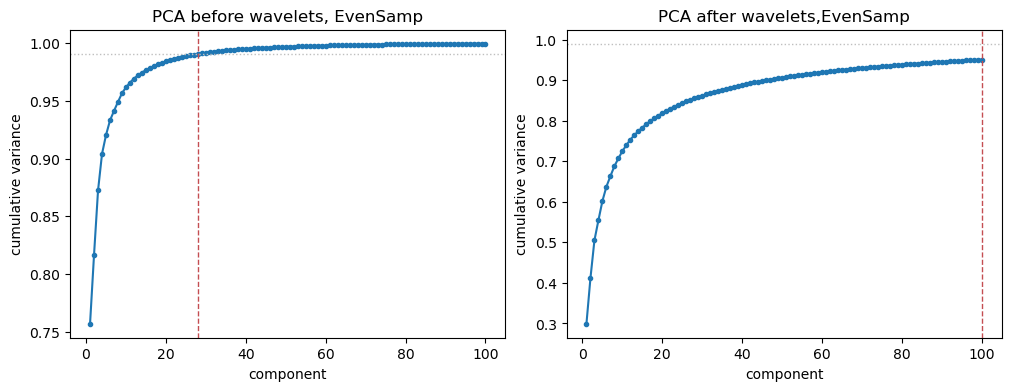

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)

pre_csv = RUN_ROOT / 'pre_wavelet_pca_cumulative_variance.csv'
post_csv = RUN_ROOT / 'post_wavelet_pca_cumulative_variance.csv'

if pre_csv.exists():
    pre = pd.read_csv(pre_csv)
    axes[0].plot(pre['component'], pre['cumulative_variance'], marker='o', ms=3)
    axes[0].axhline(float(summary.loc[0, 'pre_wavelet_pca_variance']), color='0.75', ls=':', lw=1)
    axes[0].axvline(int(summary.loc[0, 'pre_wavelet_pca_components']), color='#c44e52', ls='--', lw=1)
else:
    axes[0].text(0.5, 0.5, 'pre-wavelet PCA CSV missing', ha='center', va='center', transform=axes[0].transAxes)
axes[0].set(title='PCA before wavelets, EvenSamp', xlabel='component', ylabel='cumulative variance')

if post_csv.exists():
    post = pd.read_csv(post_csv)
    axes[1].plot(post['component'], post['cumulative_variance'], marker='o', ms=3)
    target = summary.loc[0, 'post_wavelet_pca_variance_target']
    if pd.notna(target):
        axes[1].axhline(float(target), color='0.75', ls=':', lw=1)
    axes[1].axvline(int(summary.loc[0, 'post_wavelet_pca_components']), color='#c44e52', ls='--', lw=1)
else:
    axes[1].text(0.5, 0.5, 'post-wavelet PCA CSV missing', ha='center', va='center', transform=axes[1].transAxes)
axes[1].set(title='PCA after wavelets,EvenSamp', xlabel='component', ylabel='cumulative variance')

fig.savefig(PLOT_DIR / 'pca_before_after_wavelets.png', dpi=220)
plt.show()

## Saved Slow-Mode Diagnostics

,parameter,value
0,run_name,pca_multispecies_evensamp
1,dataset,egocentered_and_normalized_distances_pre_wavel...
2,fs,120.0
3,fmin,0.5
4,fmax,54.0
5,n_freqs,25
6,pre_wavelet_pca_components,28
7,post_wavelet_pca_components,100
8,d_embed,10
9,N,1000


,species,individual_id,state_file,n_embedded_frames,n_raw_frames,n_recordings,recording_ids
0,all_species,Mus_caroli__subject__CAROLI-F-2L-741,/Users/meganbishop/slowmodeevo/outputs/single_...,432007,432016,2,24-11-20-13-48-38-086920;24-12-11-10-51-30-215001
1,all_species,Mus_caroli__subject__CAROLI-F-L-737,/Users/meganbishop/slowmodeevo/outputs/single_...,648015,648024,3,24-11-01-09-58-05-933829;24-11-13-15-34-43-317...
2,all_species,Mus_caroli__subject__CAROLI-F-L-741,/Users/meganbishop/slowmodeevo/outputs/single_...,648015,648024,3,24-11-12-12-04-12-008302;24-11-20-11-49-51-779...
3,all_species,Mus_caroli__subject__CAROLI-F-LR-741,/Users/meganbishop/slowmodeevo/outputs/single_...,648015,648024,3,24-11-12-12-05-28-185676;24-11-20-11-47-56-638...
4,all_species,Mus_caroli__subject__CAROLI-F-N-740,/Users/meganbishop/slowmodeevo/outputs/single_...,648015,648024,3,24-10-30-10-49-14-579603;24-11-13-12-57-19-190...


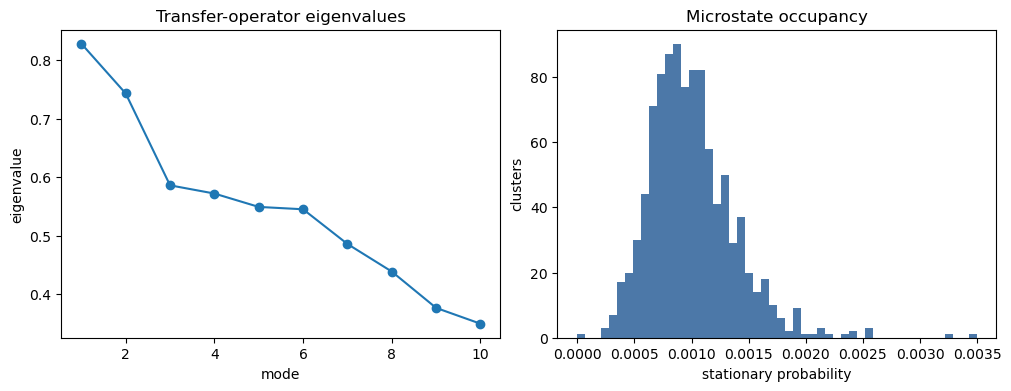

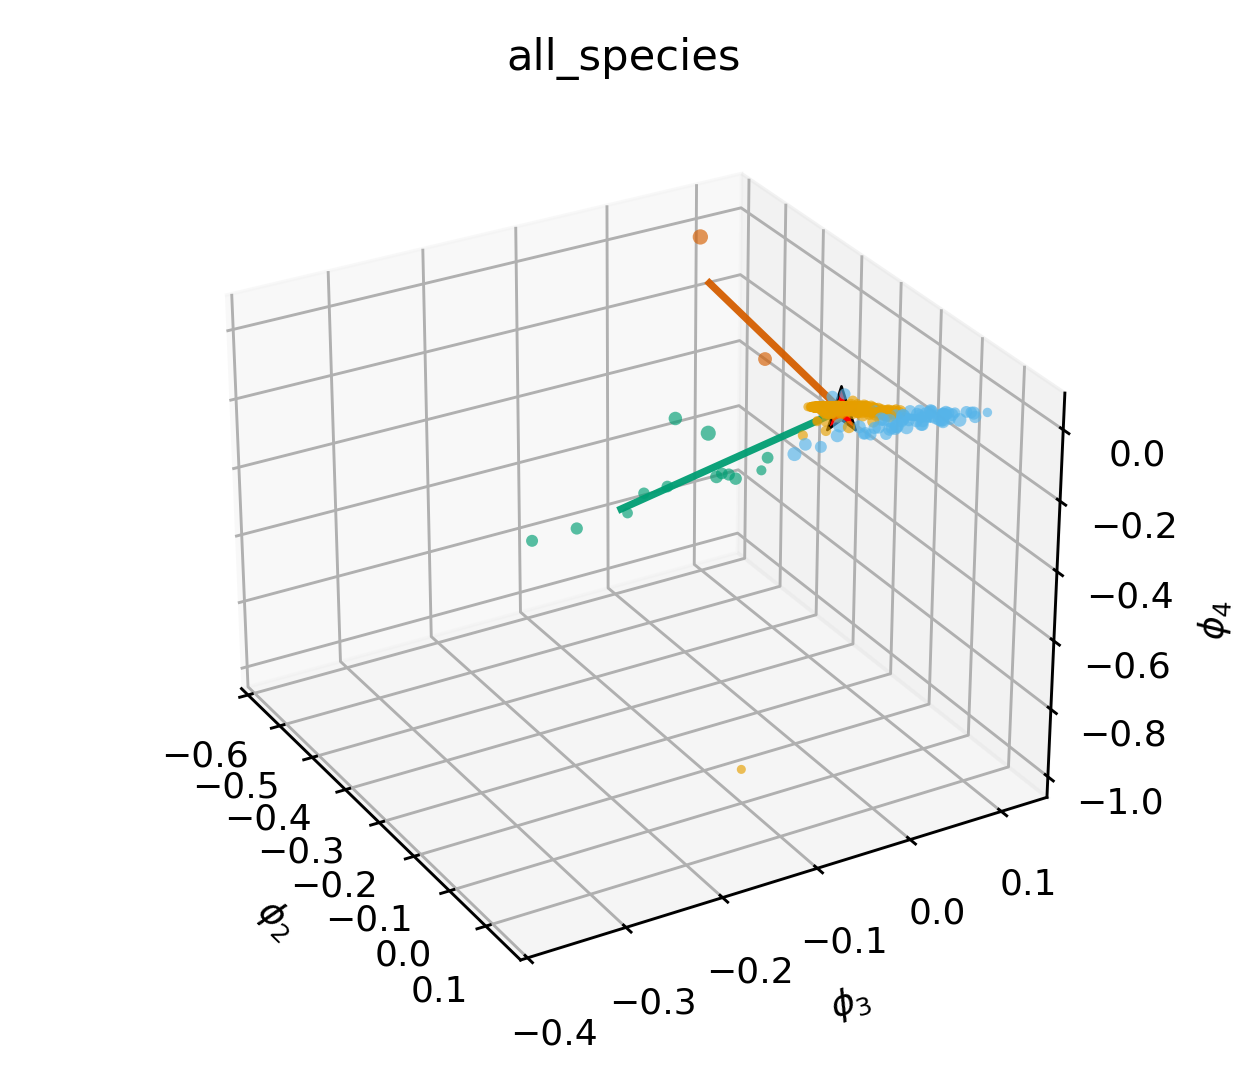

In [12]:
final_dir = RUN_ROOT / 'final_outputs'
if final_dir.exists():
    evals = np.load(final_dir / 'evals.npy')
    pi = np.load(final_dir / 'stationary_distribution.npy')
    chi = np.load(final_dir / 'chi.npy')
    params = pd.read_csv(final_dir / 'parameters.csv')
    allocations = pd.read_csv(final_dir / 'cluster_allocations_manifest.csv')
    display(params)
    display(allocations.head())

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
    axes[0].plot(np.arange(1, len(evals) + 1), np.real(evals), marker='o')
    axes[0].set(title='Transfer-operator eigenvalues', xlabel='mode', ylabel='eigenvalue')
    axes[1].hist(pi, bins=50, color='#4c78a8')
    axes[1].set(title='Microstate occupancy', xlabel='stationary probability', ylabel='clusters')
    fig.savefig(PLOT_DIR / 'slow_mode_basic_diagnostics.png', dpi=220)
    plt.show()

    arms_png = final_dir / 'arms_eigenspace.png'
    if arms_png.exists():
        display(Image(filename=str(arms_png)))
else:
    print(f'No final slow-mode outputs found at {final_dir}. Run the optional slow-mode cell in the generation notebook first.')

## Projection File Inventory

In [13]:
projection_inventory = pd.read_csv(PROJECTION_MANIFEST_CSV)
projection_inventory.to_csv(PLOT_DIR / 'projection_inventory.csv', index=False)
display(projection_inventory.groupby('species')[['n_frames']].agg(['count', 'sum']))

n_frames          
                           count       sum
species                                   
Mus_caroli                    15   9288344
Mus_musculus                  93  85754643
Mus_spretus                   16   9720360
Peromyscus_californicus       23   5183880
Peromyscus_gossypinus         20   4319900
Peromyscus_leucopus           14   3023930
Peromyscus_maniculatus       129  31751265
Peromyscus_polionotus         44  10583755